# LLM - Klasyczne metody klasyfikacji tekstu - LAB

# Zadanie

Zaadaptuj kod z notatnika *LLM - Klasyczne metody klasyfikacji tekstu - Omówienie* do problemu klasyfikacji liczby gwiazdek dla opinii z serwisu Yelp.
Możesz przygotować pętlę treningową albo w czystym PyTorchu, albo z wykorzystaniem biblioteki PyTorch Lightning.

* Wykorzystaj zbiór `Yelp/yelp_review_full` ([link](https://huggingface.co/datasets/Yelp/yelp_review_full)) zawierający opinie z serwisu Yelp (kolumna: `text`) i etykietę (kolumna: `label`) o wartościach $0,1,2,3,4$ określającą liczbę gwiazdek przyznaną przez użytkownika (a ściślej, liczbę gwiazdek minus jeden). Ponieważ mamy pięć klas, ostatnia warstwa liniowa w sieci neuronowej musi zwracać pięć wartości.
    * Zgodnie z dobrą praktyką z części treningowej wydziel dodatkową część walidacyjną i testową.
    * Ogranicz rozmiar każdej części zbioru danych (treningowej, walidacyjnej i testowej). Część treningowa nie powinna zawierać więcej niż 100k elementów.
* Do ekstrakcji cech z tekstu wykorzystaj **metodę TF-IDF** (*term frequency-inverse document frequency*) opartą o podejście typu worek słów (*bag-of-words*). Zastosuj funkcję `TfidfVectorizer` z biblioteki `scikit-learn`.
* Wykorzystaj podobną architekturę sieci (perceptron wielowarstwowy z warstwą Dropout) jak w notatniku wykładowym.



## Punkty do wykonania

1.   Napisz funkcję znajdującą i wyświetlającą $k$ elementów zbioru testowego dla których model najbardziej się myli, czyli estymuje najmniejsze prawdopodobieństwa prawdziwej klasy. Softmax jest funkcją ściśle rosnącą, więc wystarczy znaleźć elementy z najmniejszą wartością nieznormalizowanego wyjścia z sieci (logita) dla prawdziwej klasy.
2.   Zbadaj wpływ wybranych parametrów funkcji ekstrakcji cech z tekstu `TfidfVectorizer` na skuteczność wytrenowanego modelu. Uruchom kilka eksperymentów z różnymi wartościami parametrów i porównaj dokładność wytrenowanego modelu na zbiorze walidacyjnym.
3.   Zbadaj wpływ wybranych hiperparametrów modelu (np. liczba warstw liniowych modelu, rozmiary warstw) i procesu uczenia (np. początkowa wartość stopy uczenia, liczba epok, typ i parametry planisty stopy uczenia, typ i parametry optymalizatora) na skuteczność wytrenowanego modelu. Uruchom kilka eksperymentów z różnymi wartościami hiperparametrów i porównaj dokładność wytrenowanego modelu na zbiorze walidacyjnym. Następnie wykonaj finalną ewaluację najlepszego modelu na zbiorze testowym.


## Przygotowanie środowiska
Upewnij się, że notatnik jest uruchomiony na maszynie z GPU. Jesli GPU nie jest dostępne zmień typ maszyny (Runtime | Change runtime type) i wybierz T4 GPU.

In [ ]:
!nvidia-smi

Tue Mar 17 21:07:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Instalacja dodatkowych bibliotek: datasets (z biblioteki HuggingFace), TorchMetrics i W&B (Weights and Biases) Models.

In [1]:
!pip install -q datasets
!pip install -q torchmetrics
!pip install -q wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.0 MB/s eta 0:00:00


Import bibliotek.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
import wandb
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torchmetrics
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"Wersja biblioteki PyTorch: {torch.__version__}")

Wersja biblioteki PyTorch: 2.10.0+cu128


Sprawdzenie dostępności GPU.

In [ ]:
print(f"Dostępność GPU: {torch.cuda.is_available()}")
print(f"Typ GPU: {torch.cuda.get_device_name(0)}")

Dostępność GPU: True
Typ GPU: Tesla T4


In [3]:
# Logowanie do serwisu Weights&Biases monitorującego przebieg eksperymentów
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ffffff255 (ffffff255-politechnika-warszawska) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Rozwiązanie

## Model

### Pobranie danych

In [4]:
# Load the dataset
dataset = load_dataset("Yelp/yelp_review_full")
print(dataset)

test_dataset = dataset["test"]

# Wydziel część walidacyjną ze zbioru treningowego
split_dataset = dataset["train"].train_test_split(test_size=0.2)  # 80% train, 20% validation
train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

# Utwórz mniejsze podzbiory treningowe, walidacyjne i testowe
train_dataset = train_dataset.shuffle().select(range(int(len(train_dataset) * .15)))
val_dataset = val_dataset.shuffle().select(range(int(len(val_dataset) * .1)))
test_dataset = test_dataset.shuffle().select(range(int(len(test_dataset) * .4)))

print(f"Liczba próbek w zbiorze treningowym: {len(train_dataset)}")
print(f"Liczba próbek w zbiorze walidacyjnym: {len(val_dataset)}")
print(f"Liczba próbek w zbiorze testowym: {len(test_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})
Liczba próbek w zbiorze treningowym: 78000
Liczba próbek w zbiorze walidacyjnym: 13000
Liczba próbek w zbiorze testowym: 20000


In [ ]:
sample = train_dataset[123]
print(f"\nPrzykładowy element ze zbioru danych:")
print(f"{sample['text']=}")
print(f"{sample['label']=}")


Przykładowy element ze zbioru danych:
sample['text']="I rarely shop Vons because they are way, and I mean way, too pricey!!! And my Vons card never works by entering my phone number. Oober-Frustrating! \\n\\nAll in all the store is very clean, organized and comfortable to shop. You can tell they take pride in the store's appearance and what they sell. The wine and beer selection is top of the line, and I really appreciate that. The cashiers could stand to be a little friendlier in my opinion. I don't shop here often, but the times I do, they don't seem that considerate. Don't get me wrong, they are friendly and greet you, but every time I have an issue with my Vons card, they tend to make me feel like it's my fault. Not hurt by it, more just frustrated by it. \\n\\nI wouldn't recommend making this your primary stop for groceries, mainly because they are super pricey, but if you're passing by and just want to grab a quick few items, or if you're looking for a good beer and wine selecti

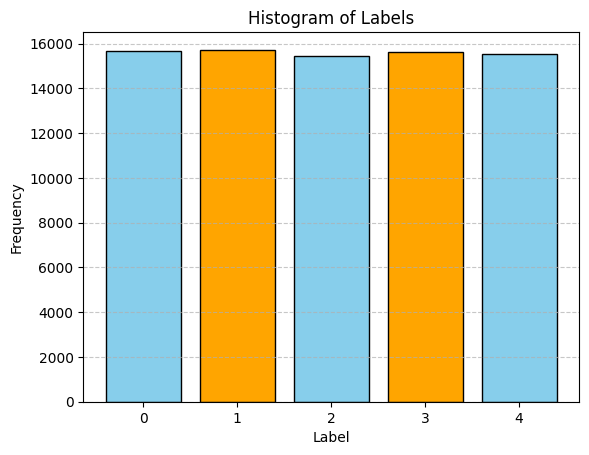

In [ ]:
# Count occurrences of each label
unique_labels, counts = np.unique(train_dataset['label'], return_counts=True)

# Plot histogram
plt.bar(unique_labels, counts, color=['skyblue', 'orange'], edgecolor='black')
plt.title('Histogram of Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xticks(unique_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Ekstrakcja cech

In [5]:
vocab_size = 10000

vectorizer = TfidfVectorizer(
    max_features=vocab_size,    # Ogranicz do max_features najczęściej występujących słów
    lowercase=True,             # Przekształć na małe litery
    analyzer='word',            # Analiza na poziomie słów (a nie pojedynczych znaków)
    ngram_range=(1, 1),         # Unigramy (pojedynczne słowa)
    stop_words="english"        # Usuń częste słowa w języku angielskim (np. a, the, and)
)

# Ekstrakcja cech
# Na zbiorze treningowym stosujemy funkcję fit_transform() która wyznacza cech i dokonuje ich ekstrakcji
train_tfidf_features = vectorizer.fit_transform(train_dataset["text"])
# Na zbiorze walidacyjnym i testowym stosujemy funkcję transform() które dokonuje ekstrakcji tych samych cech co na zbiorze treningowym
val_tfidf_features = vectorizer.transform(val_dataset["text"])
test_tfidf_features = vectorizer.transform(test_dataset["text"])

In [ ]:
print(f"Rozmiar macierzy TF-IDF dla zbioru treningowego: {train_tfidf_features.shape}")
print(f"{train_tfidf_features.dtype=}\n")

feature_names = vectorizer.get_feature_names_out()
print(f"Liczba cech: {len(feature_names)}")
print(f"Przykładowe cechy: {np.random.choice(feature_names, 20)}\n")

Rozmiar macierzy TF-IDF dla zbioru treningowego: (78000, 10000)
train_tfidf_features.dtype=dtype('float64')

Liczba cech: 10000
Przykładowe cechy: ['njust' 'ncasino' 'quiche' 'secluded' '800' 'mexico' 'selecting'
 'behaved' 'comfortably' 'directly' 'lowered' 'walnuts' 'displayed'
 'integrity' 'cashier' 'ntuna' 'blowing' 'vending' 'salads' 'plats']



In [ ]:
ndx = 123
print(f"Element zbioru treningowego o indeksie={ndx}")
print(f"{train_dataset['text'][ndx]=}")
print(f"{train_dataset['label'][ndx]=}\n")
features = train_tfidf_features[ndx]
print(f"Cechy elementu o indeksie={ndx}:")
non_zero_cols = features.nonzero()[1]

non_zero_cols = sorted(non_zero_cols)
for i in non_zero_cols:
    print(f"Kolumna: {i} ({feature_names[i]})   Waga: {features[0, i]:.5f}")

Element zbioru treningowego o indeksie=123
train_dataset['text'][ndx]="I rarely shop Vons because they are way, and I mean way, too pricey!!! And my Vons card never works by entering my phone number. Oober-Frustrating! \\n\\nAll in all the store is very clean, organized and comfortable to shop. You can tell they take pride in the store's appearance and what they sell. The wine and beer selection is top of the line, and I really appreciate that. The cashiers could stand to be a little friendlier in my opinion. I don't shop here often, but the times I do, they don't seem that considerate. Don't get me wrong, they are friendly and greet you, but every time I have an issue with my Vons card, they tend to make me feel like it's my fault. Not hurt by it, more just frustrated by it. \\n\\nI wouldn't recommend making this your primary stop for groceries, mainly because they are super pricey, but if you're passing by and just want to grab a quick few items, or if you're looking for a good beer 

Średnia liczba niezerowych cech w próbkach: 47.90


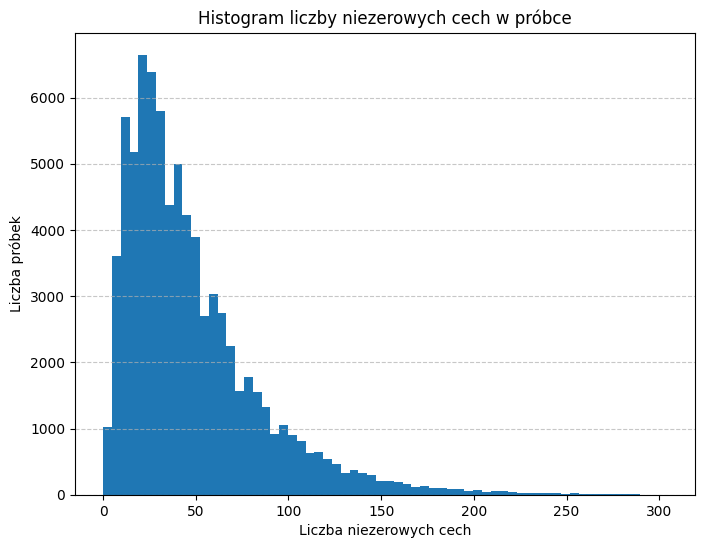

In [ ]:
# train_tfidf_features jest rzadką macierzą w formacie CSR (compressed sparse row matrix)
# Poniższy trik pozwala szybko wyznaczyć liczbę niezerowych elementów w każdym wierszu
# .indptr jest N+1 elementową tablicą taką, że indptr[i+1]-indptr[i] jest liczbą niezerowych wartości w i-tym wierszu
# Patrz: https://stackoverflow.com/questions/52299420/scipy-csr-matrix-understand-indptr

non_zero_counts = np.diff(train_tfidf_features.indptr)
print(f"Średnia liczba niezerowych cech w próbkach: {non_zero_counts.mean():.2f}")

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(non_zero_counts, bins=64)
plt.title('Histogram liczby niezerowych cech w próbce')
plt.xlabel('Liczba niezerowych cech')
plt.ylabel('Liczba próbek')
plt.grid(axis='y', linestyle='--', alpha=0.7)

### Zbiór danych PyTorch

In [6]:
def make_dataset(sparse_features, labels):
    # Zamień rzadką macierz cech na zwykłą (gęstą) macierz ndarray
    dense_features = sparse_features.astype(np.float32).todense()
    # Utwórz zbiór danych na podstawie tensora z cechami i tensora z etykietami
    dataset = TensorDataset(
        torch.from_numpy(dense_features),
        torch.tensor(labels, dtype=torch.int64)
    )
    return dataset

In [ ]:
# Utwórz trzy zbiory danych: treningowy, walidacyjny i testowy
datasets = {
    'train': make_dataset(train_tfidf_features, train_dataset['label']),
    'val': make_dataset(val_tfidf_features, val_dataset['label']),
    'test': make_dataset(test_tfidf_features, test_dataset['label'])
}

# Wyświetl przykładowy element
print(datasets['train'][0])

(tensor([0., 0., 0.,  ..., 0., 0., 0.]), tensor(4))


In [ ]:
batch_size = 256

dataloaders = {split: DataLoader(datasets[split], batch_size=batch_size, shuffle=split=='train', num_workers=0) for split in datasets}

In [ ]:
for X_batch, y_batch in dataloaders['train']:
    print(f"{X_batch.shape=}")
    print(f"{y_batch.shape=}")
    break

X_batch.shape=torch.Size([256, 10000])
y_batch.shape=torch.Size([256])


### Struktura modelu

In [7]:
class SimpleNet(nn.Module):
    def __init__(self, vocab_size: int, n_classes: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_classes = n_classes

        self.feature_extractor = nn.Sequential(
            nn.Linear(self.vocab_size, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU()
        )
        self.dropout = nn.Dropout(0.1)
        self.linear = nn.Linear(16, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)
        features = self.dropout(features)
        logits = self.linear(features)
        return logits

In [8]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
print("Urządzenie: {}".format(device))

Urządzenie: cuda:0


In [ ]:
# Utwórz model sieci neuronowej i prześlij na właściwe urządzenie
classifier = SimpleNet(vocab_size, n_classes=5)
classifier.to(device)

print(classifier)

SimpleNet(
  (feature_extractor): Sequential(
    (0): Linear(in_features=10000, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (linear): Linear(in_features=16, out_features=5, bias=True)
)


In [ ]:
# Utworzenie 5-elementowego wsadu tensorów o vocab_size elementach każdy
x = torch.rand((5, vocab_size))
print(x)
print(f"{x.shape=}\n")

x = x.to(device)        # Przenieś tensor na GPU

logits = classifier(x)
print(f"{logits=}")
print(f"{logits.shape=}\n")

probabilities = nn.functional.softmax(logits, dim=-1)
print(f"{probabilities=}")

tensor([[0.3093, 0.8817, 0.8791,  ..., 0.2819, 0.4097, 0.7831],
        [0.6706, 0.5828, 0.6154,  ..., 0.4230, 0.2187, 0.0781],
        [0.9508, 0.5547, 0.2569,  ..., 0.8606, 0.8484, 0.7161],
        [0.3852, 0.2232, 0.8819,  ..., 0.6531, 0.0410, 0.4358],
        [0.4029, 0.4898, 0.9387,  ..., 0.7448, 0.8437, 0.8634]])
x.shape=torch.Size([5, 10000])

logits=tensor([[ 0.4098,  0.1960, -0.1650,  0.3344, -0.2206],
        [ 0.3583,  0.2343, -0.1394,  0.3488, -0.1952],
        [ 0.3303,  0.2070, -0.1731,  0.3099, -0.1555],
        [ 0.3298,  0.2266, -0.1329,  0.3562, -0.1668],
        [ 0.2760,  0.1915, -0.1548,  0.2809, -0.0618]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
logits.shape=torch.Size([5, 5])

probabilities=tensor([[0.2611, 0.2108, 0.1469, 0.2421, 0.1390],
        [0.2465, 0.2178, 0.1499, 0.2442, 0.1417],
        [0.2449, 0.2165, 0.1480, 0.2399, 0.1507],
        [0.2400, 0.2165, 0.1511, 0.2464, 0.1461],
        [0.2332, 0.2143, 0.1516, 0.2344, 0.1664]], device='cuda:0',

### Pętla treningowa

In [9]:
def train(model: nn.Module, loaders: dict[DataLoader], criterion: nn.Module,
          optimizer: torch.optim.Optimizer, lr_scheduler, num_epochs: int):

    # Metryki wyznaczane dla wsadu
    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=5).to(device)

    # Run all epochs
    for epoch in range(1, num_epochs+1):

        for phase in ['train', 'val']:
            # WAŻNE - przełącz model w odpowiedni tryb
            if phase == 'train':
                model.train()  # Przełącz model w tryb treningowy
            else:
                model.eval()   # Przełącz model w tryb ewaluacyjny

            # Loop over each batch in the data loader
            for X_batch, target in tqdm(loaders[phase]):
                # Przenieś dane na odpowiednie urządzenie
                X_batch, target = X_batch.to(device), target.to(device)

                # Wyzeruj gradienty parametrów sieci
                # BARDZO WAŻNY KROK - domyślnie gradienty nie są zerowane i akumulują się dla wielu kroków przejścia w tył
                optimizer.zero_grad()

                # Przejście w przód (forward)
                # Śledzenie historii obliczeń tylko w fazie trenowania
                with torch.set_grad_enabled(phase == 'train'):
                    logits = model(X_batch)
                    _, preds = torch.max(logits, dim=1)
                    loss = criterion(logits, target)

                    # Zaktualizuj wartości metryk
                    metric_loss(loss)
                    metric_acc(preds, target)

                    # Przejście w tył (backward) i krok optymalizacji parametrów sieci tylko w fazie trenowania
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

            # Wyznacz średnie wartości metryk dla wsadu
            acc = metric_acc.compute()
            mean_loss = metric_loss.compute()
            current_lr = lr_scheduler.get_last_lr()[0]
            print(f"(Epoch {epoch}/[{phase}]) Loss:\t{mean_loss:.3f}   Accuracy: {acc:.3f}   lr: {current_lr}")
            metrics = {
                f"{phase}/loss": mean_loss,
                f"{phase}/accuracy": acc,
                f"{phase}/lr": current_lr,
            }
            wandb.log(metrics, step=epoch)

            # Wyzeruj metryki
            metric_loss.reset()
            metric_acc.reset()
            # KONIEC JEDNEJ FAZY W EPOCE (TRENING LUB WALIDACJA)

        lr_scheduler.step()
        # KONIEC EPOKI


#### Parametry pętli

In [ ]:
num_epochs = 8

# Utworzenie obiekty klasy nn.CrossEntropyLoss() obliczającego funkcję straty entropii krzyżowej
criterion = nn.CrossEntropyLoss()

# Utworzenie optymalizatora AdamW
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)

# Utworzenie planisty stopy uczenia
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

In [ ]:
run = wandb.init(project="LLM_Lab1")

train(classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)
run.finish()

100%|██████████| 305/305 [00:03<00:00, 88.67it/s]


(Epoch 1/[train]) Loss:	1.611   Accuracy: 0.250   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 120.91it/s]


(Epoch 1/[val]) Loss:	1.588   Accuracy: 0.374   lr: 0.0001


100%|██████████| 305/305 [00:03<00:00, 81.06it/s]


...

100%|██████████| 305/305 [00:03<00:00, 101.10it/s]


(Epoch 8/[train]) Loss:	1.113   Accuracy: 0.533   lr: 1.3425421036992098e-05


100%|██████████| 51/51 [00:00<00:00, 115.41it/s]

(Epoch 8/[val]) Loss:	1.115   Accuracy: 0.541   lr: 1.3425421036992098e-05


train/accuracy,▁▄▆▇████
train/loss,█▇▅▃▂▂▁▁
train/lr,██▇▆▄▃▂▁
val/accuracy,▂▁▆▇▇███
val/loss,█▆▄▃▂▁▁▁
val/lr,██▇▆▄▃▂▁
train/accuracy,0.53265
train/loss,1.11306
train/lr,1e-05
val/accuracy,0.54131
val/loss,1.11516


In [ ]:
torch.save(classifier.state_dict(), 'my_model_weights.pth')

### Ewaluacja

In [ ]:
# Indeks elementu ze zbioru testowego
ndx = 42

x, target = datasets['test'][ndx]
print(f"Opinia: {test_dataset[ndx]['text']}")
print(f"Prawdziwa klasa: {target}")

x = x.to(device)

# BARDZO WAŻNE
classifier.eval()

with torch.inference_mode():
    # torch.inference_mode - opcjonalne, ale przyśpiesz wykonanie, bo nie jest tworzony graf obliczeń
    logits = classifier(x)

print(f"Wyjście z sieci (logity): {logits}")
probas = torch.nn.functional.softmax(logits, dim=-1)
print(f"Rozkład prawdopodobieństwa klas: {probas}")
print(f"Predykowana klasa: {logits.argmax(dim=-1)}")


Opinia: Disgusted by server who goes by the name of \"Mike\" and how he served my children!!!!!!!!
Prawdziwa klasa: 0
Wyjście z sieci (logity): tensor([ 1.2205,  0.5170, -0.0700, -0.2312, -0.6611], device='cuda:0')
Rozkład prawdopodobieństwa klas: tensor([0.4637, 0.2295, 0.1276, 0.1086, 0.0706], device='cuda:0')
Predykowana klasa: 0


In [ ]:
preds_l = []
targets_l = []

classifier.eval()

for X_batch, target in tqdm(dataloaders['test']):
    # Przenieś dane na odpowiednie urządzenie
    X_batch, target = X_batch.to(device), target.to(device)

    # Przejście w przód (forward)
    # Śledzenie historii obliczeń tylko w fazie trenowania
    with torch.inference_mode():
        logits = classifier(X_batch)
        _, preds = torch.max(logits, dim=-1)
        preds_l.extend(preds.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

preds = np.array(preds_l)
targets = np.array(targets_l)

print(f"\n{preds.shape=}")
print(f"{targets.shape=}")

100%|██████████| 79/79 [00:00<00:00, 109.91it/s]


preds.shape=(20000,)
targets.shape=(20000,)


In [ ]:
# Nazwy klas
labels = ['1✪', '2✪', '3✪', '4✪', '5✪']

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

          1✪       0.61      0.81      0.69      3998
          2✪       0.53      0.42      0.47      4042
          3✪       0.47      0.42      0.44      3962
          4✪       0.42      0.31      0.36      3955
          5✪       0.60      0.75      0.67      4043

    accuracy                           0.54     20000
   macro avg       0.53      0.54      0.53     20000
weighted avg       0.53      0.54      0.53     20000



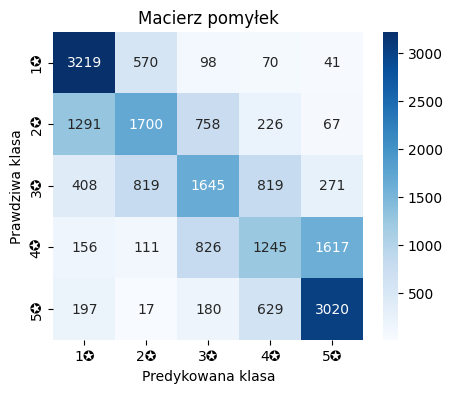

In [ ]:
cm = confusion_matrix(targets, preds)

# Create a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Macierz pomyłek')
plt.xlabel('Predykowana klasa')
plt.ylabel('Prawdziwa klasa')
plt.show()


## Wykonane punkty

### Punkt 1.

Napisz funkcję znajdującą i wyświetlającą $k$ elementów zbioru testowego dla których model najbardziej się myli, czyli estymuje najmniejsze prawdopodobieństwa prawdziwej klasy. Softmax jest funkcją ściśle rosnącą, więc wystarczy znaleźć elementy z najmniejszą wartością nieznormalizowanego wyjścia z sieci (logita) dla prawdziwej klasy.

In [ ]:
def worst_preds(k: int, model: nn.Module, feature_data, text_data):
    dataloader = DataLoader(feature_data, batch_size=len(feature_data), shuffle=False, num_workers=0)
    X_batch, y_batch = next(iter(dataloader))
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    model.eval()
    with torch.inference_mode():
        logits = model(X_batch)
        target_logits = logits.gather(1, y_batch.unsqueeze(1)).squeeze(1)
        sorted, index = target_logits.sort()
        # print(f"{target_logits=}")
        # print(f"{sorted=}")
        # print(f"{sorted[index.argsort()]=}")    # index.argsort() allows conversion back into the original order
        # print(f"{target_logits[index[:3]]=}")   # index[:n] provides the original indexes of n lowest logits
        # print(f"{"\n".join(text_data[index[:k]])}\n")   # printable in one line but more structured info is probably more useful:
        for i in range(k):
            idx = int(index[i]) # had to convert to int, tensor didn't work for some reason
            print(f"{i+1}.\t{text_data[idx]}")
            print(f"{y_batch[idx]=}")
            print(f"{logits[idx]=}\n")
    return index

In [ ]:
print(type(test_dataset["text"]))

<class 'datasets.arrow_dataset.Column'>


In [ ]:
worst_preds(10, classifier, datasets["test"], test_dataset["text"])

1.	Ok so went back and ordered the full sandwich and soup.  It came with chips also, which you do not get when you get suckered into the half soup half sandwich thing.  This time: I felt like I got what I paid for!  Much better and will be back!!
y_batch[idx]=tensor(4, device='cuda:0')
logits[idx]=tensor([ 1.7034,  2.0155,  0.8374, -0.8879, -2.4278], device='cuda:0')

2.	So I went here TWICE on Valentine's weekend (no, not on the 14th) with the lady friend. We went around 8 one night and then the next afternoon for the 2 for 1 from 2-6. We went there not because I'm cheap - it was practical considering both of our money limitations. And she's not cheap either.\n\nFrom my experience - for under 20 bucks it ain't bad at all (I would give it 4 stars, but I'm giving it 5 due to the jerks who gave it 1 or 2 stars for reasons mentioned below). Reading other people's reviews for this buffet and others I think that a lot of people go in with the wrong expectations/perspective:\n\nIt's a friggi

tensor([2696, 3696,  476,  ..., 1347, 1507, 3669], device='cuda:0')

#### Wnioski

Co ciekawe, model najbardziej się myli w przypadku skrajnych recenzji, przypisując ich poprawnej klasie najmniejsze logity i przeciwnej stronie najwyższe.

Powierzchownie analizując przykładowe teksty, błędy te wynikają najpewniej z wyłapywania słów, które bez kontekstu mają wydźwięk negatywny, np. w sytuacjach, w których recenzent opisuje, jak otrzymana usługa była lepsza niż jego początkowe oczekiwania albo jak obsługa pozytywnie zachowała się w niefortunnej sytuacji.

### Punkt 2.

Zbadaj wpływ wybranych parametrów funkcji ekstrakcji cech z tekstu `TfidfVectorizer` na skuteczność wytrenowanego modelu. Uruchom kilka eksperymentów z różnymi wartościami parametrów i porównaj dokładność wytrenowanego modelu na zbiorze walidacyjnym.


In [ ]:
def test_vectorizer_params(vectorizer: TfidfVectorizer):
    # Ekstrakcja cech
    # Na zbiorze treningowym stosujemy funkcję fit_transform() która wyznacza cech i dokonuje ich ekstrakcji
    train_tfidf_features = vectorizer.fit_transform(train_dataset["text"])
    # Na zbiorze walidacyjnym i testowym stosujemy funkcję transform() które dokonuje ekstrakcji tych samych cech co na zbiorze treningowym
    val_tfidf_features = vectorizer.transform(val_dataset["text"])
    test_tfidf_features = vectorizer.transform(test_dataset["text"])
    datasets = {
        'train': make_dataset(train_tfidf_features, train_dataset['label']),
        'val': make_dataset(val_tfidf_features, val_dataset['label']),
        'test': make_dataset(test_tfidf_features, test_dataset['label'])
    }
    batch_size = 256
    dataloaders = {split: DataLoader(datasets[split], batch_size=batch_size, shuffle=split=='train', num_workers=0) for split in datasets}

    classifier = SimpleNet(vocab_size, n_classes=5)
    classifier.to(device)

    num_epochs = 16
    # Utworzenie obiekty klasy nn.CrossEntropyLoss() obliczającego funkcję straty entropii krzyżowej
    criterion = nn.CrossEntropyLoss()
    # Utworzenie optymalizatora AdamW
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
    # Utworzenie planisty stopy uczenia
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    run = wandb.init(project="LLM_Lab1")
    train(classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)
    run.finish()

    preds_l = []
    targets_l = []
    classifier.eval()
    for X_batch, target in tqdm(dataloaders['val']):
        # Przenieś dane na odpowiednie urządzenie
        X_batch, target = X_batch.to(device), target.to(device)
        # Przejście w przód (forward)
        # Śledzenie historii obliczeń tylko w fazie trenowania
        with torch.inference_mode():
            logits = classifier(X_batch)
            _, preds = torch.max(logits, dim=-1)
            preds_l.extend(preds.cpu().numpy())
            targets_l.extend(target.cpu().numpy())
    preds = np.array(preds_l)
    targets = np.array(targets_l)
    print(f"\n{preds.shape=}")
    print(f"{targets.shape=}")
    # Nazwy klas
    labels = ['1✪', '2✪', '3✪', '4✪', '5✪']
    report = classification_report(targets, preds, target_names = labels)
    print(report)
    cm = confusion_matrix(targets, preds)
    # Create a heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Macierz pomyłek')
    plt.xlabel('Predykowana klasa')
    plt.ylabel('Prawdziwa klasa')
    plt.show()

#### Eksperyment 0. (wartości "domyślne")

100%|██████████| 305/305 [00:02<00:00, 105.76it/s]


(Epoch 1/[train]) Loss:	1.603   Accuracy: 0.229   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 124.26it/s]


(Epoch 1/[val]) Loss:	1.581   Accuracy: 0.339   lr: 0.0001


100%|██████████| 305/305 [00:02<00:00, 105.24it/s]


...

100%|██████████| 51/51 [00:00<00:00, 129.69it/s]

(Epoch 16/[val]) Loss:	0.986   Accuracy: 0.566   lr: 1.0864662381854632e-05


train/accuracy,▁▄▆▇▇▇██████████
train/loss,█▇▅▄▃▂▂▂▁▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▄▆▇████████████
val/loss,█▇▄▃▂▂▁▁▁▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.58668
train/loss,0.95202
train/lr,1e-05
val/accuracy,0.56554
val/loss,0.98566


100%|██████████| 51/51 [00:00<00:00, 162.00it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.70      0.75      0.72      2673
          2✪       0.50      0.47      0.48      2594
          3✪       0.47      0.47      0.47      2616
          4✪       0.48      0.44      0.46      2518
          5✪       0.65      0.69      0.67      2599

    accuracy                           0.57     13000
   macro avg       0.56      0.56      0.56     13000
weighted avg       0.56      0.57      0.56     13000



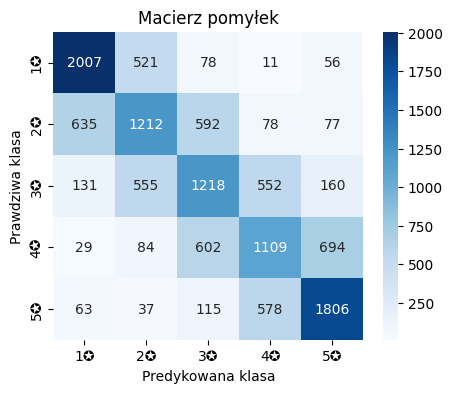

In [ ]:
vocab_size = 10000
vectorizer = TfidfVectorizer(
    max_features=vocab_size,    # Ogranicz do max_features najczęściej występujących słów
    lowercase=True,             # Przekształć na małe litery
    analyzer='word',            # Analiza na poziomie słów (a nie pojedynczych znaków)
    ngram_range=(1, 1),         # Unigramy (pojedynczne słowa)
    stop_words="english"        # Usuń częste słowa w języku angielskim (np. a, the, and)
)
test_vectorizer_params(vectorizer)

#### Eksperyment 1. (+50% `max_features`)

100%|██████████| 305/305 [00:03<00:00, 77.06it/s]


(Epoch 1/[train]) Loss:	1.605   Accuracy: 0.262   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 87.39it/s]


(Epoch 1/[val]) Loss:	1.585   Accuracy: 0.357   lr: 0.0001


100%|██████████| 305/305 [00:03<00:00, 83.91it/s]


...

100%|██████████| 51/51 [00:00<00:00, 94.06it/s]

(Epoch 16/[val]) Loss:	1.025   Accuracy: 0.552   lr: 1.0864662381854632e-05


train/accuracy,▁▄▅▆▆▇▇▇▇███████
train/loss,█▇▆▄▃▂▂▂▂▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▃▄▆▇▇▇█████████
val/loss,█▇▅▃▂▂▂▁▁▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.56899
train/loss,0.98821
train/lr,1e-05
val/accuracy,0.55246
val/loss,1.02502


100%|██████████| 51/51 [00:00<00:00, 98.24it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.70      0.75      0.73      2673
          2✪       0.49      0.46      0.47      2594
          3✪       0.44      0.45      0.44      2616
          4✪       0.44      0.38      0.41      2518
          5✪       0.64      0.71      0.67      2599

    accuracy                           0.55     13000
   macro avg       0.54      0.55      0.55     13000
weighted avg       0.54      0.55      0.55     13000



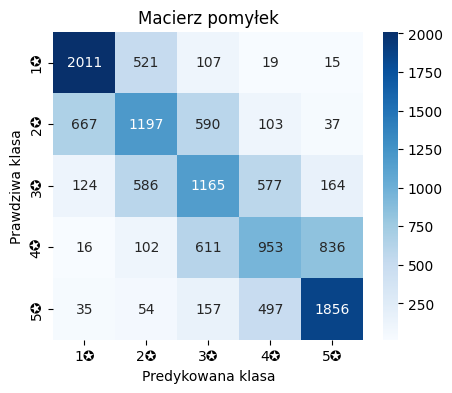

In [ ]:
vocab_size = 15000
vectorizer = TfidfVectorizer(
    max_features=vocab_size,    # Ogranicz do max_features najczęściej występujących słów
    lowercase=True,             # Przekształć na małe litery
    analyzer='word',            # Analiza na poziomie słów (a nie pojedynczych znaków)
    ngram_range=(1, 1),         # Unigramy (pojedynczne słowa)
    stop_words="english"        # Usuń częste słowa w języku angielskim (np. a, the, and)
)
test_vectorizer_params(vectorizer)

#### Eksperyment 2. (-50% `max_features`)

100%|██████████| 305/305 [00:02<00:00, 137.35it/s]


(Epoch 1/[train]) Loss:	1.613   Accuracy: 0.198   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 181.59it/s]


(Epoch 1/[val]) Loss:	1.601   Accuracy: 0.201   lr: 0.0001


100%|██████████| 305/305 [00:02<00:00, 140.37it/s]


...

100%|██████████| 51/51 [00:00<00:00, 181.23it/s]

(Epoch 16/[val]) Loss:	1.031   Accuracy: 0.559   lr: 1.0864662381854632e-05


train/accuracy,▁▂▅▅▆▇▇█████████
train/loss,██▆▅▄▃▂▂▂▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▅▅▅▆▇██████████
val/loss,█▇▆▄▃▃▂▂▂▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.55073
train/loss,1.03495
train/lr,1e-05
val/accuracy,0.55869
val/loss,1.03061


100%|██████████| 51/51 [00:00<00:00, 245.98it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.69      0.75      0.72      2673
          2✪       0.49      0.45      0.47      2594
          3✪       0.47      0.45      0.46      2616
          4✪       0.48      0.45      0.47      2518
          5✪       0.63      0.68      0.66      2599

    accuracy                           0.56     13000
   macro avg       0.55      0.56      0.55     13000
weighted avg       0.55      0.56      0.55     13000



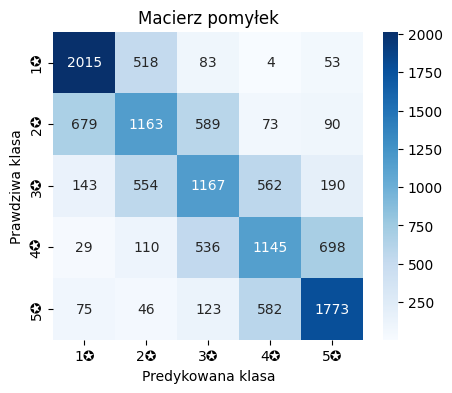

In [ ]:
vocab_size = 5000
vectorizer = TfidfVectorizer(
    max_features=vocab_size,    # Ogranicz do max_features najczęściej występujących słów
    lowercase=True,             # Przekształć na małe litery
    analyzer='word',            # Analiza na poziomie słów (a nie pojedynczych znaków)
    ngram_range=(1, 1),         # Unigramy (pojedynczne słowa)
    stop_words="english"        # Usuń częste słowa w języku angielskim (np. a, the, and)
)
test_vectorizer_params(vectorizer)

#### Eksperyment 3. (`ngram_range=(1,2)`)

100%|██████████| 305/305 [00:03<00:00, 101.07it/s]


(Epoch 1/[train]) Loss:	1.607   Accuracy: 0.204   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 116.75it/s]


(Epoch 1/[val]) Loss:	1.588   Accuracy: 0.260   lr: 0.0001


100%|██████████| 305/305 [00:02<00:00, 104.13it/s]


...

100%|██████████| 51/51 [00:00<00:00, 113.13it/s]

(Epoch 16/[val]) Loss:	0.978   Accuracy: 0.574   lr: 1.0864662381854632e-05


train/accuracy,▁▃▅▆▇▇▇█████████
train/loss,█▇▆▅▄▃▂▂▂▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▄▅▇▇███████████
val/loss,█▇▆▄▃▂▂▂▁▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.59412
train/loss,0.95192
train/lr,1e-05
val/accuracy,0.57354
val/loss,0.9784


100%|██████████| 51/51 [00:00<00:00, 127.74it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.71      0.76      0.73      2673
          2✪       0.50      0.49      0.50      2594
          3✪       0.49      0.45      0.47      2616
          4✪       0.48      0.47      0.47      2518
          5✪       0.65      0.69      0.67      2599

    accuracy                           0.57     13000
   macro avg       0.57      0.57      0.57     13000
weighted avg       0.57      0.57      0.57     13000



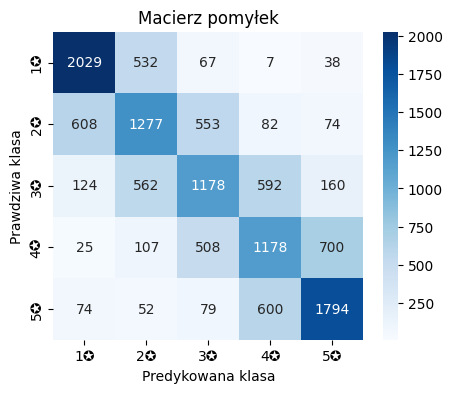

In [ ]:
vocab_size = 10000
vectorizer = TfidfVectorizer(
    max_features=vocab_size,    # Ogranicz do max_features najczęściej występujących słów
    lowercase=True,             # Przekształć na małe litery
    analyzer='word',            # Analiza na poziomie słów (a nie pojedynczych znaków)
    ngram_range=(1, 2),         # N-gramy od 1 do 2 słów
    stop_words="english"        # Usuń częste słowa w języku angielskim (np. a, the, and)
)
test_vectorizer_params(vectorizer)

#### Eksperyment 4. (`ngram_range=(1,3)`)

100%|██████████| 305/305 [00:03<00:00, 101.59it/s]


(Epoch 1/[train]) Loss:	1.610   Accuracy: 0.319   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 128.16it/s]


(Epoch 1/[val]) Loss:	1.582   Accuracy: 0.357   lr: 0.0001


100%|██████████| 305/305 [00:03<00:00, 94.79it/s]


...

100%|██████████| 51/51 [00:00<00:00, 119.15it/s]

(Epoch 16/[val]) Loss:	0.967   Accuracy: 0.576   lr: 1.0864662381854632e-05


train/accuracy,▁▂▄▆▇▇▇▇████████
train/loss,█▇▅▄▃▂▂▂▁▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▁▆▇▇███████████
val/loss,█▆▄▃▂▂▁▁▁▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.59404
train/loss,0.93079
train/lr,1e-05
val/accuracy,0.57577
val/loss,0.96708


100%|██████████| 51/51 [00:00<00:00, 151.94it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.71      0.75      0.73      2673
          2✪       0.51      0.48      0.50      2594
          3✪       0.48      0.47      0.48      2616
          4✪       0.48      0.46      0.47      2518
          5✪       0.67      0.71      0.69      2599

    accuracy                           0.58     13000
   macro avg       0.57      0.57      0.57     13000
weighted avg       0.57      0.58      0.57     13000



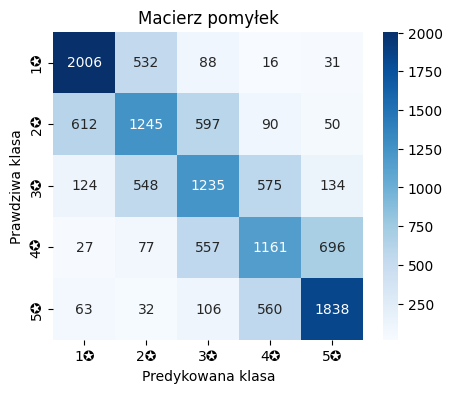

In [ ]:
vocab_size = 10000
vectorizer = TfidfVectorizer(
    max_features=vocab_size,    # Ogranicz do max_features najczęściej występujących słów
    lowercase=True,             # Przekształć na małe litery
    analyzer='word',            # Analiza na poziomie słów (a nie pojedynczych znaków)
    ngram_range=(1, 3),         # N-gramy od 1 do 3 słów
    stop_words="english"        # Usuń częste słowa w języku angielskim (np. a, the, and)
)
test_vectorizer_params(vectorizer)

#### Wnioski

**Dokładność na zbiorze walidacyjnym:**

0.   Wartości "domyślne" (`max_features=10000, ngram_range=(1,1)`) — 56.554%
1.   `max_features=15000` — 55.246%
2.   `max_features=5000` — 55.869%
3.   `ngram_range=(1,2)` — 57.354%
4.   `ngram_range=(1,3)` — **57.577%**

Ani zwiększenie, ani zmniejszenie zasobu słownictwa nie poprawiło jakości modelu. Zauważalny był natomiast ogromny wpływ tej wartości na zużycie pamięci (np. 20000 było niemożliwe do wykonania przez przekroczenie zasobów sprzętowych Colab).

Rozszerzenie zakresu n-gramów poprawiło jakość modelu, lecz na poziomie różnicy 1 punkta procentowego dokładności.

### Punkt 3.

Zbadaj wpływ wybranych hiperparametrów modelu (np. liczba warstw liniowych modelu, rozmiary warstw) i procesu uczenia (np. początkowa wartość stopy uczenia, liczba epok, typ i parametry planisty stopy uczenia, typ i parametry optymalizatora) na skuteczność wytrenowanego modelu. Uruchom kilka eksperymentów z różnymi wartościami hiperparametrów i porównaj dokładność wytrenowanego modelu na zbiorze walidacyjnym. Następnie wykonaj finalną ewaluację najlepszego modelu na zbiorze testowym.

In [10]:
def test_other_params(classifier, optimizer, lr_scheduler, num_epochs, dataset='val'):
    # Utworzenie obiekty klasy nn.CrossEntropyLoss() obliczającego funkcję straty entropii krzyżowej
    criterion = nn.CrossEntropyLoss()

    run = wandb.init(project="LLM_Lab1")
    train(classifier, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)
    run.finish()

    preds_l = []
    targets_l = []
    classifier.eval()
    for X_batch, target in tqdm(dataloaders[dataset]):
        # Przenieś dane na odpowiednie urządzenie
        X_batch, target = X_batch.to(device), target.to(device)
        # Przejście w przód (forward)
        # Śledzenie historii obliczeń tylko w fazie trenowania
        with torch.inference_mode():
            logits = classifier(X_batch)
            _, preds = torch.max(logits, dim=-1)
            preds_l.extend(preds.cpu().numpy())
            targets_l.extend(target.cpu().numpy())
    preds = np.array(preds_l)
    targets = np.array(targets_l)
    print(f"\n{preds.shape=}")
    print(f"{targets.shape=}")
    # Nazwy klas
    labels = ['1✪', '2✪', '3✪', '4✪', '5✪']
    report = classification_report(targets, preds, target_names = labels)
    print(report)
    cm = confusion_matrix(targets, preds)
    # Create a heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Macierz pomyłek')
    plt.xlabel('Predykowana klasa')
    plt.ylabel('Prawdziwa klasa')
    plt.show()

In [11]:
# Ekstrakcja cech
vocab_size = 10000
vectorizer = TfidfVectorizer(
    max_features=vocab_size,    # Ogranicz do max_features najczęściej występujących słów
    lowercase=True,             # Przekształć na małe litery
    analyzer='word',            # Analiza na poziomie słów (a nie pojedynczych znaków)
    ngram_range=(1, 2),         # N-gramy od 1 do 2 słów
    stop_words="english"        # Usuń częste słowa w języku angielskim (np. a, the, and)
)
# Na zbiorze treningowym stosujemy funkcję fit_transform() która wyznacza cech i dokonuje ich ekstrakcji
train_tfidf_features = vectorizer.fit_transform(train_dataset["text"])
# Na zbiorze walidacyjnym i testowym stosujemy funkcję transform() które dokonuje ekstrakcji tych samych cech co na zbiorze treningowym
val_tfidf_features = vectorizer.transform(val_dataset["text"])
test_tfidf_features = vectorizer.transform(test_dataset["text"])
datasets = {
    'train': make_dataset(train_tfidf_features, train_dataset['label']),
    'val': make_dataset(val_tfidf_features, val_dataset['label']),
    'test': make_dataset(test_tfidf_features, test_dataset['label'])
}
batch_size = 256
dataloaders = {split: DataLoader(datasets[split], batch_size=batch_size, shuffle=split=='train', num_workers=0) for split in datasets}

#### Eksperyment 0. (wartości "domyślne")

100%|██████████| 305/305 [00:04<00:00, 76.07it/s]


(Epoch 1/[train]) Loss:	1.606   Accuracy: 0.278   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 115.30it/s]


(Epoch 1/[val]) Loss:	1.574   Accuracy: 0.340   lr: 0.0001


100%|██████████| 305/305 [00:02<00:00, 102.04it/s]


...

100%|██████████| 51/51 [00:00<00:00, 123.06it/s]

(Epoch 16/[val]) Loss:	0.970   Accuracy: 0.576   lr: 9.657457896300802e-05


train/accuracy,▁▄▆▇▇▇▇▇▇▇▇█████
train/loss,█▇▅▄▃▃▂▂▂▂▂▂▂▁▁▁
train/lr,██▇▆▅▃▂▁▁▁▂▃▅▆▇█
val/accuracy,▁▄▆▇▇███████████
val/loss,█▆▅▃▃▂▂▂▂▂▂▂▁▁▁▁
val/lr,██▇▆▅▃▂▁▁▁▂▃▅▆▇█
train/accuracy,0.58979
train/loss,0.95274
train/lr,0.0001
val/accuracy,0.576
val/loss,0.97014


100%|██████████| 51/51 [00:00<00:00, 148.36it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.71      0.76      0.74      2673
          2✪       0.51      0.49      0.50      2594
          3✪       0.50      0.47      0.48      2616
          4✪       0.48      0.47      0.48      2518
          5✪       0.66      0.69      0.67      2599

    accuracy                           0.58     13000
   macro avg       0.57      0.57      0.57     13000
weighted avg       0.57      0.58      0.57     13000



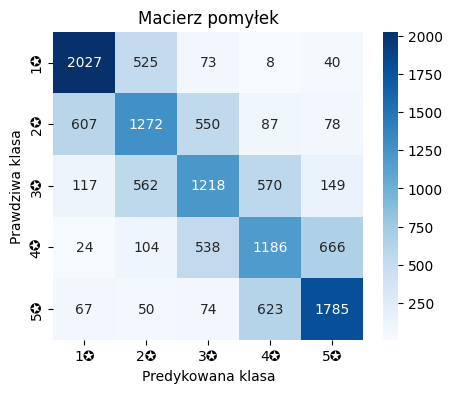

In [ ]:
classifier = SimpleNet(vocab_size, n_classes=5).to(device)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
num_epochs = 16
test_other_params(classifier, optimizer, lr_scheduler, num_epochs)

#### Eksperyment 1. (dodatkowa warstwa modelu)

In [ ]:
class DeeperNet(nn.Module):
    def __init__(self, vocab_size: int, n_classes: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_classes = n_classes

        self.feature_extractor = nn.Sequential(
            nn.Linear(self.vocab_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.dropout = nn.Dropout(0.1)
        self.linear = nn.Linear(16, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)
        features = self.dropout(features)
        logits = self.linear(features)
        return logits

100%|██████████| 305/305 [00:03<00:00, 99.32it/s]


(Epoch 1/[train]) Loss:	1.606   Accuracy: 0.218   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 96.44it/s]


(Epoch 1/[val]) Loss:	1.592   Accuracy: 0.312   lr: 0.0001


100%|██████████| 305/305 [00:03<00:00, 84.50it/s] 


...

100%|██████████| 51/51 [00:00<00:00, 100.64it/s]

(Epoch 16/[val]) Loss:	1.066   Accuracy: 0.517   lr: 1.0864662381854632e-05


train/accuracy,▁▄▅▆▆▇▇▇▇███████
train/loss,█▇▅▃▂▂▂▂▁▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▄▄▆▇▇▇█████████
val/loss,█▆▃▂▂▂▁▁▁▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.54278
train/loss,1.00797
train/lr,1e-05
val/accuracy,0.51692
val/loss,1.06637


100%|██████████| 51/51 [00:00<00:00, 152.27it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.67      0.67      0.67      2673
          2✪       0.45      0.44      0.44      2594
          3✪       0.41      0.45      0.43      2616
          4✪       0.42      0.39      0.40      2518
          5✪       0.63      0.63      0.63      2599

    accuracy                           0.52     13000
   macro avg       0.52      0.52      0.52     13000
weighted avg       0.52      0.52      0.52     13000



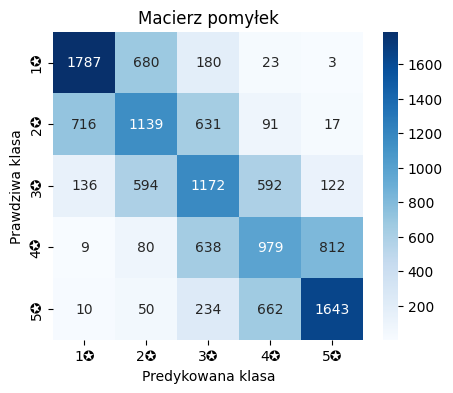

In [ ]:
classifier = DeeperNet(vocab_size, n_classes=5).to(device)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
num_epochs = 16
test_other_params(classifier, optimizer, lr_scheduler, num_epochs)

#### Eksperyment 2. (większe warstwy ukryte)

In [13]:
class WiderNet(nn.Module):
    def __init__(self, vocab_size: int, n_classes: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_classes = n_classes

        self.feature_extractor = nn.Sequential(
            nn.Linear(self.vocab_size, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
        )
        self.dropout = nn.Dropout(0.1)
        self.linear = nn.Linear(32, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)
        features = self.dropout(features)
        logits = self.linear(features)
        return logits

100%|██████████| 305/305 [00:03<00:00, 99.00it/s]


(Epoch 1/[train]) Loss:	1.574   Accuracy: 0.352   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 113.72it/s]


(Epoch 1/[val]) Loss:	1.484   Accuracy: 0.458   lr: 0.0001


100%|██████████| 305/305 [00:03<00:00, 95.48it/s]


...

100%|██████████| 51/51 [00:00<00:00, 117.97it/s]

(Epoch 16/[val]) Loss:	0.956   Accuracy: 0.580   lr: 1.0864662381854632e-05


train/accuracy,▁▄▆▇▇▇▇█████████
train/loss,█▆▄▃▂▂▂▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▃▇▇████████████
val/loss,█▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.62544
train/loss,0.86527
train/lr,1e-05
val/accuracy,0.57954
val/loss,0.95625


100%|██████████| 51/51 [00:00<00:00, 138.82it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.72      0.75      0.73      2673
          2✪       0.52      0.50      0.51      2594
          3✪       0.49      0.47      0.48      2616
          4✪       0.48      0.48      0.48      2518
          5✪       0.66      0.70      0.68      2599

    accuracy                           0.58     13000
   macro avg       0.57      0.58      0.58     13000
weighted avg       0.58      0.58      0.58     13000



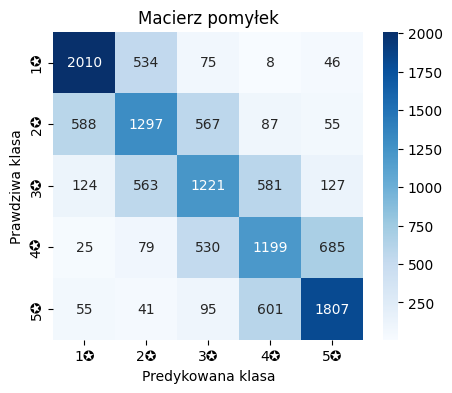

In [ ]:
classifier = WiderNet(vocab_size, n_classes=5).to(device)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
num_epochs = 16
test_other_params(classifier, optimizer, lr_scheduler, num_epochs)

#### Eksperyment 3. (większa początkowa stopa uczenia)

100%|██████████| 305/305 [00:03<00:00, 89.23it/s]


(Epoch 1/[train]) Loss:	1.217   Accuracy: 0.462   lr: 0.001


100%|██████████| 51/51 [00:00<00:00, 117.40it/s]


(Epoch 1/[val]) Loss:	0.971   Accuracy: 0.573   lr: 0.001


100%|██████████| 305/305 [00:02<00:00, 101.89it/s]


...

100%|██████████| 51/51 [00:00<00:00, 122.56it/s]

(Epoch 16/[val]) Loss:	1.111   Accuracy: 0.556   lr: 1.9511286200400937e-05


train/accuracy,▁▄▅▅▆▆▆▇▇▇▇█████
train/loss,█▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▇█▇▅▄▅▃▂▃▂▁▁▁▁▁▁
val/loss,▁▁▁▂▃▃▄▄▅▆▇▇▇███
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.73908
train/loss,0.66694
train/lr,2e-05
val/accuracy,0.55608
val/loss,1.1114


100%|██████████| 51/51 [00:00<00:00, 137.17it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.69      0.71      0.70      2673
          2✪       0.50      0.51      0.50      2594
          3✪       0.47      0.45      0.46      2616
          4✪       0.46      0.45      0.46      2518
          5✪       0.64      0.65      0.65      2599

    accuracy                           0.56     13000
   macro avg       0.55      0.55      0.55     13000
weighted avg       0.55      0.56      0.56     13000



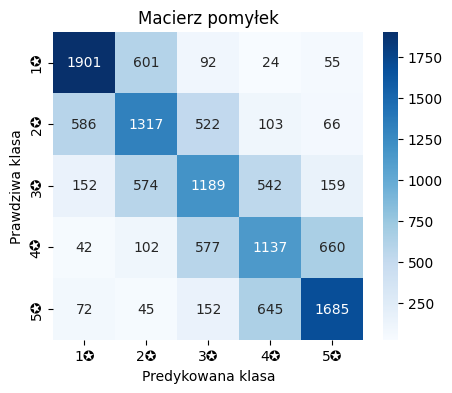

In [ ]:
classifier = SimpleNet(vocab_size, n_classes=5).to(device)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
num_epochs = 16
test_other_params(classifier, optimizer, lr_scheduler, num_epochs)

#### Eksperyment 4. (inny typ planisty stopy uczenia)

100%|██████████| 305/305 [00:03<00:00, 94.76it/s]


(Epoch 1/[train]) Loss:	1.596   Accuracy: 0.252   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 95.91it/s]


(Epoch 1/[val]) Loss:	1.565   Accuracy: 0.318   lr: 0.0001


100%|██████████| 305/305 [00:03<00:00, 87.65it/s] 


...

100%|██████████| 51/51 [00:00<00:00, 118.25it/s]

(Epoch 16/[val]) Loss:	0.989   Accuracy: 0.564   lr: 4.6329123015975305e-05


train/accuracy,▁▃▅▅▆▆▇▇▇▇▇█████
train/loss,█▇▅▄▃▃▂▂▂▂▂▁▁▁▁▁
train/lr,█▇▇▆▆▅▅▄▄▃▃▂▂▂▁▁
val/accuracy,▁▃▅▆▇▇▇▇████████
val/loss,█▆▅▄▃▂▂▂▂▁▁▁▁▁▁▁
val/lr,█▇▇▆▆▅▅▄▄▃▃▂▂▂▁▁
train/accuracy,0.58467
train/loss,0.95145
train/lr,5e-05
val/accuracy,0.56385
val/loss,0.98867


100%|██████████| 51/51 [00:00<00:00, 150.65it/s]



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.72      0.75      0.73      2673
          2✪       0.50      0.47      0.48      2594
          3✪       0.46      0.47      0.46      2616
          4✪       0.46      0.41      0.43      2518
          5✪       0.65      0.71      0.68      2599

    accuracy                           0.56     13000
   macro avg       0.56      0.56      0.56     13000
weighted avg       0.56      0.56      0.56     13000



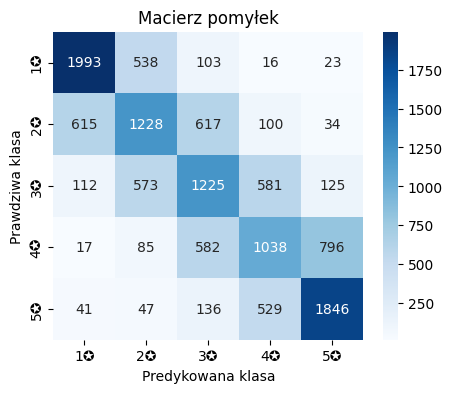

In [ ]:
classifier = SimpleNet(vocab_size, n_classes=5).to(device)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
num_epochs = 16
test_other_params(classifier, optimizer, lr_scheduler, num_epochs)

#### Eksperyment 5. (inny typ optymalizatora)

100%|██████████| 305/305 [00:02<00:00, 104.57it/s]


(Epoch 1/[train]) Loss:	1.621   Accuracy: 0.198   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 121.61it/s]


(Epoch 1/[val]) Loss:	1.622   Accuracy: 0.201   lr: 0.0001


100%|██████████| 305/305 [00:02<00:00, 105.88it/s]


...

100%|██████████| 51/51 [00:00<00:00, 117.89it/s]

(Epoch 16/[val]) Loss:	1.621   Accuracy: 0.201   lr: 1.0864662381854632e-05


train/accuracy,▃▄▂▂▂▅▂▄▃█▄▁▃▆▅▄
train/loss,█▇▆▅▅▄▃▃▃▂▂▂▂▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▇▆▅▅▄▃▃▂▂▂▂▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.1981
train/loss,1.61978
train/lr,1e-05
val/accuracy,0.20123
val/loss,1.62125


100%|██████████| 51/51 [00:00<00:00, 140.28it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



preds.shape=(13000,)
targets.shape=(13000,)
              precision    recall  f1-score   support

          1✪       0.00      0.00      0.00      2673
          2✪       0.00      0.00      0.00      2594
          3✪       0.20      1.00      0.34      2616
          4✪       0.00      0.00      0.00      2518
          5✪       0.00      0.00      0.00      2599

    accuracy                           0.20     13000
   macro avg       0.04      0.20      0.07     13000
weighted avg       0.04      0.20      0.07     13000



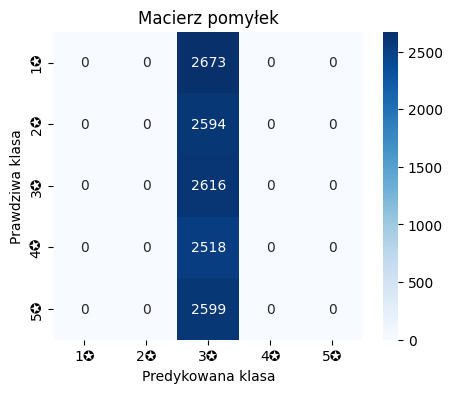

In [ ]:
classifier = SimpleNet(vocab_size, n_classes=5).to(device)
optimizer = torch.optim.SGD(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
num_epochs = 16
test_other_params(classifier, optimizer, lr_scheduler, num_epochs)

#### Wnioski

**Dokładność na zbiorze walidacyjnym:**

0. Wartości "domyślne" (warstwy 64/16, AdamW, początkowe LR 1e-4, CosineAnnealingLR) — 57.6%
1. Warstwy 64/32/16 — 51.692%
2. Warstwy 128/32 — **57.954%**
3. Początkowe LR 1e-3 — 55.608%
4. ExponentialLR — 56.385%
5. SGD — 20.123%

Najbardziej zauważalna różnica nastąpiła przy użyciu optymalizatora SGD zamiast AdamW — dokładność spadła do poziomu klasyfikatora losowego (model zaczął predyktować zawsze 3 gwiazdki).

Najlepszym modelem okazał się ten z poszerzonymi warstwami ukrytymi, który osiągnął prawie 58% dokładności.

Co ciekawe, dodanie nowej warstwy zamiast poszerzenia istniejących doprowadziło do znaczącego pogorszenia modelu.

#### Test najlepszego modelu

100%|██████████| 305/305 [00:04<00:00, 65.27it/s] 


(Epoch 1/[train]) Loss:	1.583   Accuracy: 0.268   lr: 0.0001


100%|██████████| 51/51 [00:00<00:00, 98.44it/s]


(Epoch 1/[val]) Loss:	1.507   Accuracy: 0.391   lr: 0.0001


100%|██████████| 305/305 [00:03<00:00, 86.25it/s] 


...

100%|██████████| 51/51 [00:00<00:00, 129.37it/s]

(Epoch 16/[val]) Loss:	0.954   Accuracy: 0.580   lr: 1.0864662381854632e-05


train/accuracy,▁▅▆▇▇▇▇█████████
train/loss,█▆▄▃▂▂▂▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
val/accuracy,▁▅▇▇▇███████████
val/loss,█▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁
val/lr,███▇▇▆▆▅▄▄▃▃▂▂▁▁
train/accuracy,0.62256
train/loss,0.8743
train/lr,1e-05
val/accuracy,0.58015
val/loss,0.95414


100%|██████████| 79/79 [00:00<00:00, 147.82it/s]



preds.shape=(20000,)
targets.shape=(20000,)
              precision    recall  f1-score   support

          1✪       0.70      0.74      0.72      4012
          2✪       0.52      0.49      0.50      4043
          3✪       0.47      0.47      0.47      3959
          4✪       0.49      0.46      0.48      4016
          5✪       0.66      0.70      0.68      3970

    accuracy                           0.57     20000
   macro avg       0.57      0.57      0.57     20000
weighted avg       0.57      0.57      0.57     20000



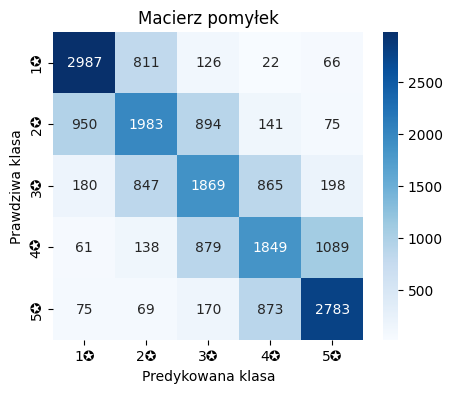

In [15]:
num_epochs = 16
classifier = WiderNet(vocab_size, n_classes=5).to(device)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
test_other_params(classifier, optimizer, lr_scheduler, num_epochs, dataset="test")

Na zbiorze testowym udało się nawet przebić 58% dokładności.

### Podsumowanie

Na podstawie uzyskanych macierzy pomyłek widać, że (te dobrze wytrenowane, tj. nieużywające SGD) modele są najbardziej trafne w przypadku skrajnych recenzji 1- lub 5-gwiazdkowych. Intuicyjnie można przyjąć, że wynika to z braku możliwości pomyłki o odpowiednio 1 gwiazdkę mniej/więcej.

Funkcja z punktu 1. natomiast pokazuje, że jak już dochodzi do pomyłki w tych skrajnych klasach, to jest ona zazwyczaj ogromna, co obrazuje kluczową wadę podejścia typu *bag-of-words*, tj. brak kontekstu analizowanych słów.

Poprawa jakości w przypadku poszerzenia zakresu n-gramów skutkuje zauważalną poprawą, najpewniej ze względu na wyłapywanie najprostszych przypadków, w których model analizujący pojedyncze słowa mógłby się pomylić (np. "not bad", "not very good").